In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.gridspec as gridspec
import os
from metrics import truthfulness, cognitive_dissonance, normalize_each_row_sum, calculate_beliefs
from agents import confirmation_bias
import networkx as nx

import numpy as np

def edge_weights_from_beliefs(G, public_t, private_t, s, x_metric="l2"):
    """
    Computes directed weights w_ij(t) using:
        x_ij(t) = || p_i(t) - q_j(t) ||
        w_ij(t) = exp(-(x_ij(t)/s)^2) / sum_l a_il

    Parameters
    ----------
    G : nx.Graph
        Base (undirected) graph defining who can talk to whom (a_ij).
    public_t : array (N, d)
        Public belief vectors p_i at timestep t.
    private_t : array (N, d)
        Private belief vectors q_i at timestep t.
    s : float
        Scale parameter.
    x_metric : {"l2","l1","cosine"}
        Distance metric for x_ij.

    Returns
    -------
    edgelist : list[(i,j)]
        Directed edges (both directions for each undirected edge).
    w : np.ndarray
        Directed weights aligned with edgelist.
    """
    P = np.asarray(public_t)
    Q = np.asarray(private_t)
    if P.ndim != 2 or Q.ndim != 2 or P.shape != Q.shape:
        raise ValueError(f"public_t and private_t must both be (N,d). Got {P.shape=} {Q.shape=}")

    deg = dict(G.degree())  # sum_l a_il for unweighted adjacency

    def dist(pi, qj):
        if x_metric == "l2":
            return np.linalg.norm(pi - qj)
        elif x_metric == "l1":
            return np.sum(np.abs(pi - qj))
        elif x_metric == "cosine":
            ni = np.linalg.norm(pi) + 1e-12
            nj = np.linalg.norm(qj) + 1e-12
            return 1.0 - float(np.dot(pi, qj) / (ni * nj))
        else:
            raise ValueError(f"Unknown x_metric: {x_metric}")

    edgelist = []
    w = []

    for (u, v) in G.edges():
        # add both directions because weights are directed
        for i, j in [(u, v), (v, u)]:
            di = deg[i] if deg[i] > 0 else 1
            x_ij = dist(P[int(i)], Q[int(j)])
            w_ij = np.exp(- (x_ij / s) ** 2) / di
            edgelist.append((i, j))
            w.append(w_ij)

    return edgelist, np.asarray(w, dtype=float)

def is_periodic_wrap_edge(i, j, pos, L):
    xi, yi = pos[i]
    xj, yj = pos[j]

    # horizontal wrap (0 <-> L-1)
    if yi == yj and abs(xi - xj) == L - 1:
        return True
    # vertical wrap (0 <-> L-1)
    if xi == xj and abs(yi - yj) == L - 1:
        return True

    return False

def plot_grid_with_two_colorbars(selected_ts, node_values, 
                                 public_beliefs, private_beliefs,
                                title, savepath,
                                G, pos,
                                node_cmap, edge_cmap,
                                edge_vmin, edge_vmax,
                                s, belief_type):
    fig = plt.figure(figsize=(20, 24))
    gs = gridspec.GridSpec(
        nrows=6, ncols=3,
        height_ratios=[1, 1, 1, 0.1, 0.05, 0.1],  # 3 rows plots + edgebar + nodebar
        hspace=0.25, wspace=0.05
    )

    axes = []
    for r in range(3):
        for c in range(3):
            axes.append(fig.add_subplot(gs[r, c]))

    # fig.suptitle(title, fontsize=28)

    for i, t in enumerate(selected_ts):
        ax = axes[i]

        # nodes
        nx.draw_networkx_nodes(
            G, pos,
            node_color=node_values[t], cmap=node_cmap,
            vmin=0, vmax=1, node_size=500, ax=ax
        )

        # edges

        if t==selected_ts[-1]:
            edgelist, w = edge_weights_from_beliefs(
                G,
                public_t=public_beliefs[0, t],
                private_t=private_beliefs[0, t-1],
                s=s
            )
        else:

            edgelist, w = edge_weights_from_beliefs(
                G,
                public_t=public_beliefs[0, t+1],
                private_t=private_beliefs[0, t],
                s=s
            )


        # Filter out wrap-around directed edges
        E_keep, W_keep = [], []
        for (i, j), wij in zip(edgelist, w):
            if is_periodic_wrap_edge(i, j, pos, L):
                continue
            E_keep.append((i, j))
            W_keep.append(wij)

        # Split into two sets so opposite directions don’t overlap:
        # use a canonical undirected key {min,max} to assign consistent curvature
        E_pos, W_pos = [], []
        E_neg, W_neg = [], []

        for (i, j), wij in zip(E_keep, W_keep):
            a, b = (i, j) if i < j else (j, i)
            # if edge is (a->b) use +rad, if (b->a) use -rad
            if (i, j) == (a, b):
                E_pos.append((i, j)); W_pos.append(wij)
            else:
                E_neg.append((i, j)); W_neg.append(wij)

        # Draw the two directions with opposite curvature
        nx.draw_networkx_edges(
            G, pos,
            edgelist=E_pos,
            edge_color=np.asarray(W_pos),
            edge_cmap=edge_cmap,
            edge_vmin=edge_vmin, edge_vmax=edge_vmax,
            arrows=True, arrowstyle='-|>', arrowsize=8,
            width=2.0, alpha=0.85,
            connectionstyle="arc3,rad=0.2",
            min_source_margin=12,   # <-- increase to shorten near tail
            min_target_margin=12,   # <-- increase to shorten near head
            ax=ax
        )
        nx.draw_networkx_edges(
            G, pos,
            edgelist=E_neg,
            edge_color=np.asarray(W_neg),
            edge_cmap=edge_cmap,
            edge_vmin=edge_vmin, edge_vmax=edge_vmax,
            arrows=True, arrowstyle='-|>', arrowsize=8,
            width=2.0, alpha=0.85,
            connectionstyle="arc3,rad=0.2",
            min_source_margin=12,   # <-- increase to shorten near tail
            min_target_margin=12,   # <-- increase to shorten near head
            ax=ax
        )

        for n in G.nodes():
            x, y = pos[n]
            value = node_values[t][n]   # belief value of node n at time t

            # If belief < 0.4 → white text, otherwise black
            label_color = "white" if value < 0.35 else "black"

            ax.text(
                x, y, str(n),
                color=label_color,
                fontsize=18,
                ha="center", va="center",
                zorder=10   # make sure text is above nodes
            )

        ax.set_title(fr"Timestep $t={t}$", fontsize=28)
        ax.axis("off")

    # --- dedicated colorbar axes (bottom two rows) ---
    cax_edges = fig.add_subplot(gs[3, :])
    cax_nodes = fig.add_subplot(gs[5, :])

    sm_edges = mpl.cm.ScalarMappable(cmap=edge_cmap, norm=mpl.colors.Normalize(edge_vmin, edge_vmax))
    sm_edges.set_array([])
    cb_edges = fig.colorbar(sm_edges, cax=cax_edges, orientation="horizontal")
    edge_ticks = np.linspace(0.0, edge_vmax, 5)
    cb_edges.set_ticks(edge_ticks)
    cb_edges.set_ticklabels([f"{t:.2f}" for t in edge_ticks])

    # move label/ticks if you are using the “on top” style
    # cb_edges.ax.xaxis.set_label_position("bottom")
    # cb_edges.ax.xaxis.tick_top()

    # font sizes
    cb_edges.ax.tick_params(labelsize=20)
    cb_edges.set_label(
        r"Edge weights $w_{ij}$",
        fontsize=28,
        labelpad=10
    )

    sm_nodes = mpl.cm.ScalarMappable(cmap=node_cmap, norm=mpl.colors.Normalize(0, 1))
    sm_nodes.set_array([])
    cb_nodes = fig.colorbar(sm_nodes, cax=cax_nodes, orientation="horizontal")

    belief_ticks = np.arange(0.0, 1.01, 0.2)
    cb_nodes.set_ticks(belief_ticks)
    cb_nodes.set_ticklabels([f"{t:.1f}" for t in belief_ticks])

    cb_nodes.ax.tick_params(labelsize=20)
    cb_nodes.set_label(
        f"Belief in {'true' if belief_type == 'T' else 'false'} hypothesis",
        fontsize=28,
        labelpad=10
    )

    fig.savefig(savepath, bbox_inches="tight", dpi=400)
    plt.show()

def plot_grid2x3_with_two_colorbars(selected_ts, node_values, 
                                    private_beliefs, public_beliefs,
                                   title, savepath,
                                   G, pos,
                                   node_cmap, edge_cmap,
                                   edge_vmin, edge_vmax,
                                   s, belief_type):
    fig = plt.figure(figsize=(20, 18))
    gs = gridspec.GridSpec(
        nrows=5, ncols=3,
        height_ratios=[1, 1, 0.1, 0.05, 0.1],  # 2 rows plots + edgebar + nodebar
        hspace=0.30, wspace=0.05
    )

    axes = []
    for r in range(2):
        for c in range(3):
            axes.append(fig.add_subplot(gs[r, c]))

    # fig.suptitle(title, fontsize=28)

    for i, t in enumerate(selected_ts):
        ax = axes[i]

        nx.draw_networkx_nodes(
            G, pos,
            node_color=node_values[t], cmap=node_cmap,
            vmin=0, vmax=1, node_size=500, ax=ax
        )

        if t==selected_ts[-1]:
            edgelist, w = edge_weights_from_beliefs(
                G,
                public_t=public_beliefs[0, t],
                private_t=private_beliefs[0, t-1],
                s=s
            )
        else:

            edgelist, w = edge_weights_from_beliefs(
                G,
                public_t=public_beliefs[0, t+1],
                private_t=private_beliefs[0, t],
                s=s
            )

        # Filter out wrap-around directed edges
        E_keep, W_keep = [], []
        for (i, j), wij in zip(edgelist, w):
            if is_periodic_wrap_edge(i, j, pos, L):
                continue
            E_keep.append((i, j))
            W_keep.append(wij)

        # Split into two sets so opposite directions don’t overlap:
        # use a canonical undirected key {min,max} to assign consistent curvature
        E_pos, W_pos = [], []
        E_neg, W_neg = [], []

        for (i, j), wij in zip(E_keep, W_keep):
            a, b = (i, j) if i < j else (j, i)
            # if edge is (a->b) use +rad, if (b->a) use -rad
            if (i, j) == (a, b):
                E_pos.append((i, j)); W_pos.append(wij)
            else:
                E_neg.append((i, j)); W_neg.append(wij)

        # Draw the two directions with opposite curvature
        nx.draw_networkx_edges(
            G, pos,
            edgelist=E_pos,
            edge_color=np.asarray(W_pos),
            edge_cmap=edge_cmap,
            edge_vmin=edge_vmin, edge_vmax=edge_vmax,
            arrows=True, arrowstyle='-|>', arrowsize=8,
            width=2.0, alpha=0.85,
            connectionstyle="arc3,rad=0.2",
            min_source_margin=12,   # <-- increase to shorten near tail
            min_target_margin=12,   # <-- increase to shorten near head
            ax=ax
        )
        nx.draw_networkx_edges(
            G, pos,
            edgelist=E_neg,
            edge_color=np.asarray(W_neg),
            edge_cmap=edge_cmap,
            edge_vmin=edge_vmin, edge_vmax=edge_vmax,
            arrows=True, arrowstyle='-|>', arrowsize=8,
            width=2.0, alpha=0.85,
            connectionstyle="arc3,rad=0.2",
            min_source_margin=12,   # <-- increase to shorten near tail
            min_target_margin=12,   # <-- increase to shorten near head
            ax=ax
        )

        for n in G.nodes():
            x, y = pos[n]
            value = node_values[t][n]   # belief value of node n at time t

            # If belief < 0.4 → white text, otherwise black
            label_color = "white" if value < 0.35 else "black"

            ax.text(
                x, y, str(n),
                color=label_color,
                fontsize=18,
                ha="center", va="center",
                zorder=10   # make sure text is above nodes
            )

        ax.set_title(fr"Timestep $t={t}$", fontsize=28)
        ax.axis("off")

    cax_edges = fig.add_subplot(gs[2, :])
    cax_nodes = fig.add_subplot(gs[4, :])

    # ----- Edge colorbar -----
    sm_edges = mpl.cm.ScalarMappable(
        cmap=edge_cmap,
        norm=mpl.colors.Normalize(edge_vmin, edge_vmax)
    )
    sm_edges.set_array([])

    cb_edges = fig.colorbar(sm_edges, cax=cax_edges, orientation="horizontal")

    # ticks 0.0 → 1.0 with step 0.2
    edge_ticks = np.linspace(0.0, edge_vmax, 5)
    cb_edges.set_ticks(edge_ticks)
    cb_edges.set_ticklabels([f"{t:.2f}" for t in edge_ticks])

    # font sizes
    cb_edges.ax.tick_params(labelsize=20)
    cb_edges.set_label(r"Edge weights $w_{ij}$", fontsize=28, labelpad=10)

    # optional: put ticks/label on top (looks cleaner when stacked)
    # cb_edges.ax.xaxis.set_label_position("top")
    # cb_edges.ax.xaxis.tick_top()

    # ----- Node (belief) colorbar -----
    sm_nodes = mpl.cm.ScalarMappable(
        cmap=node_cmap,
        norm=mpl.colors.Normalize(0, 1)
    )
    sm_nodes.set_array([])

    cb_nodes = fig.colorbar(sm_nodes, cax=cax_nodes, orientation="horizontal")

    belief_ticks = np.arange(0.0, 1.01, 0.2)
    cb_nodes.set_ticks(belief_ticks)
    cb_nodes.set_ticklabels([f"{t:.1f}" for t in belief_ticks])

    cb_nodes.ax.tick_params(labelsize=20)
    cb_nodes.set_label(
        f"Belief in {'true' if belief_type == 'T' else 'false'} hypothesis",
        fontsize=28,
        labelpad=10
    )
    fig.savefig(savepath, bbox_inches="tight", dpi=400)
    plt.show()


(100, 100)


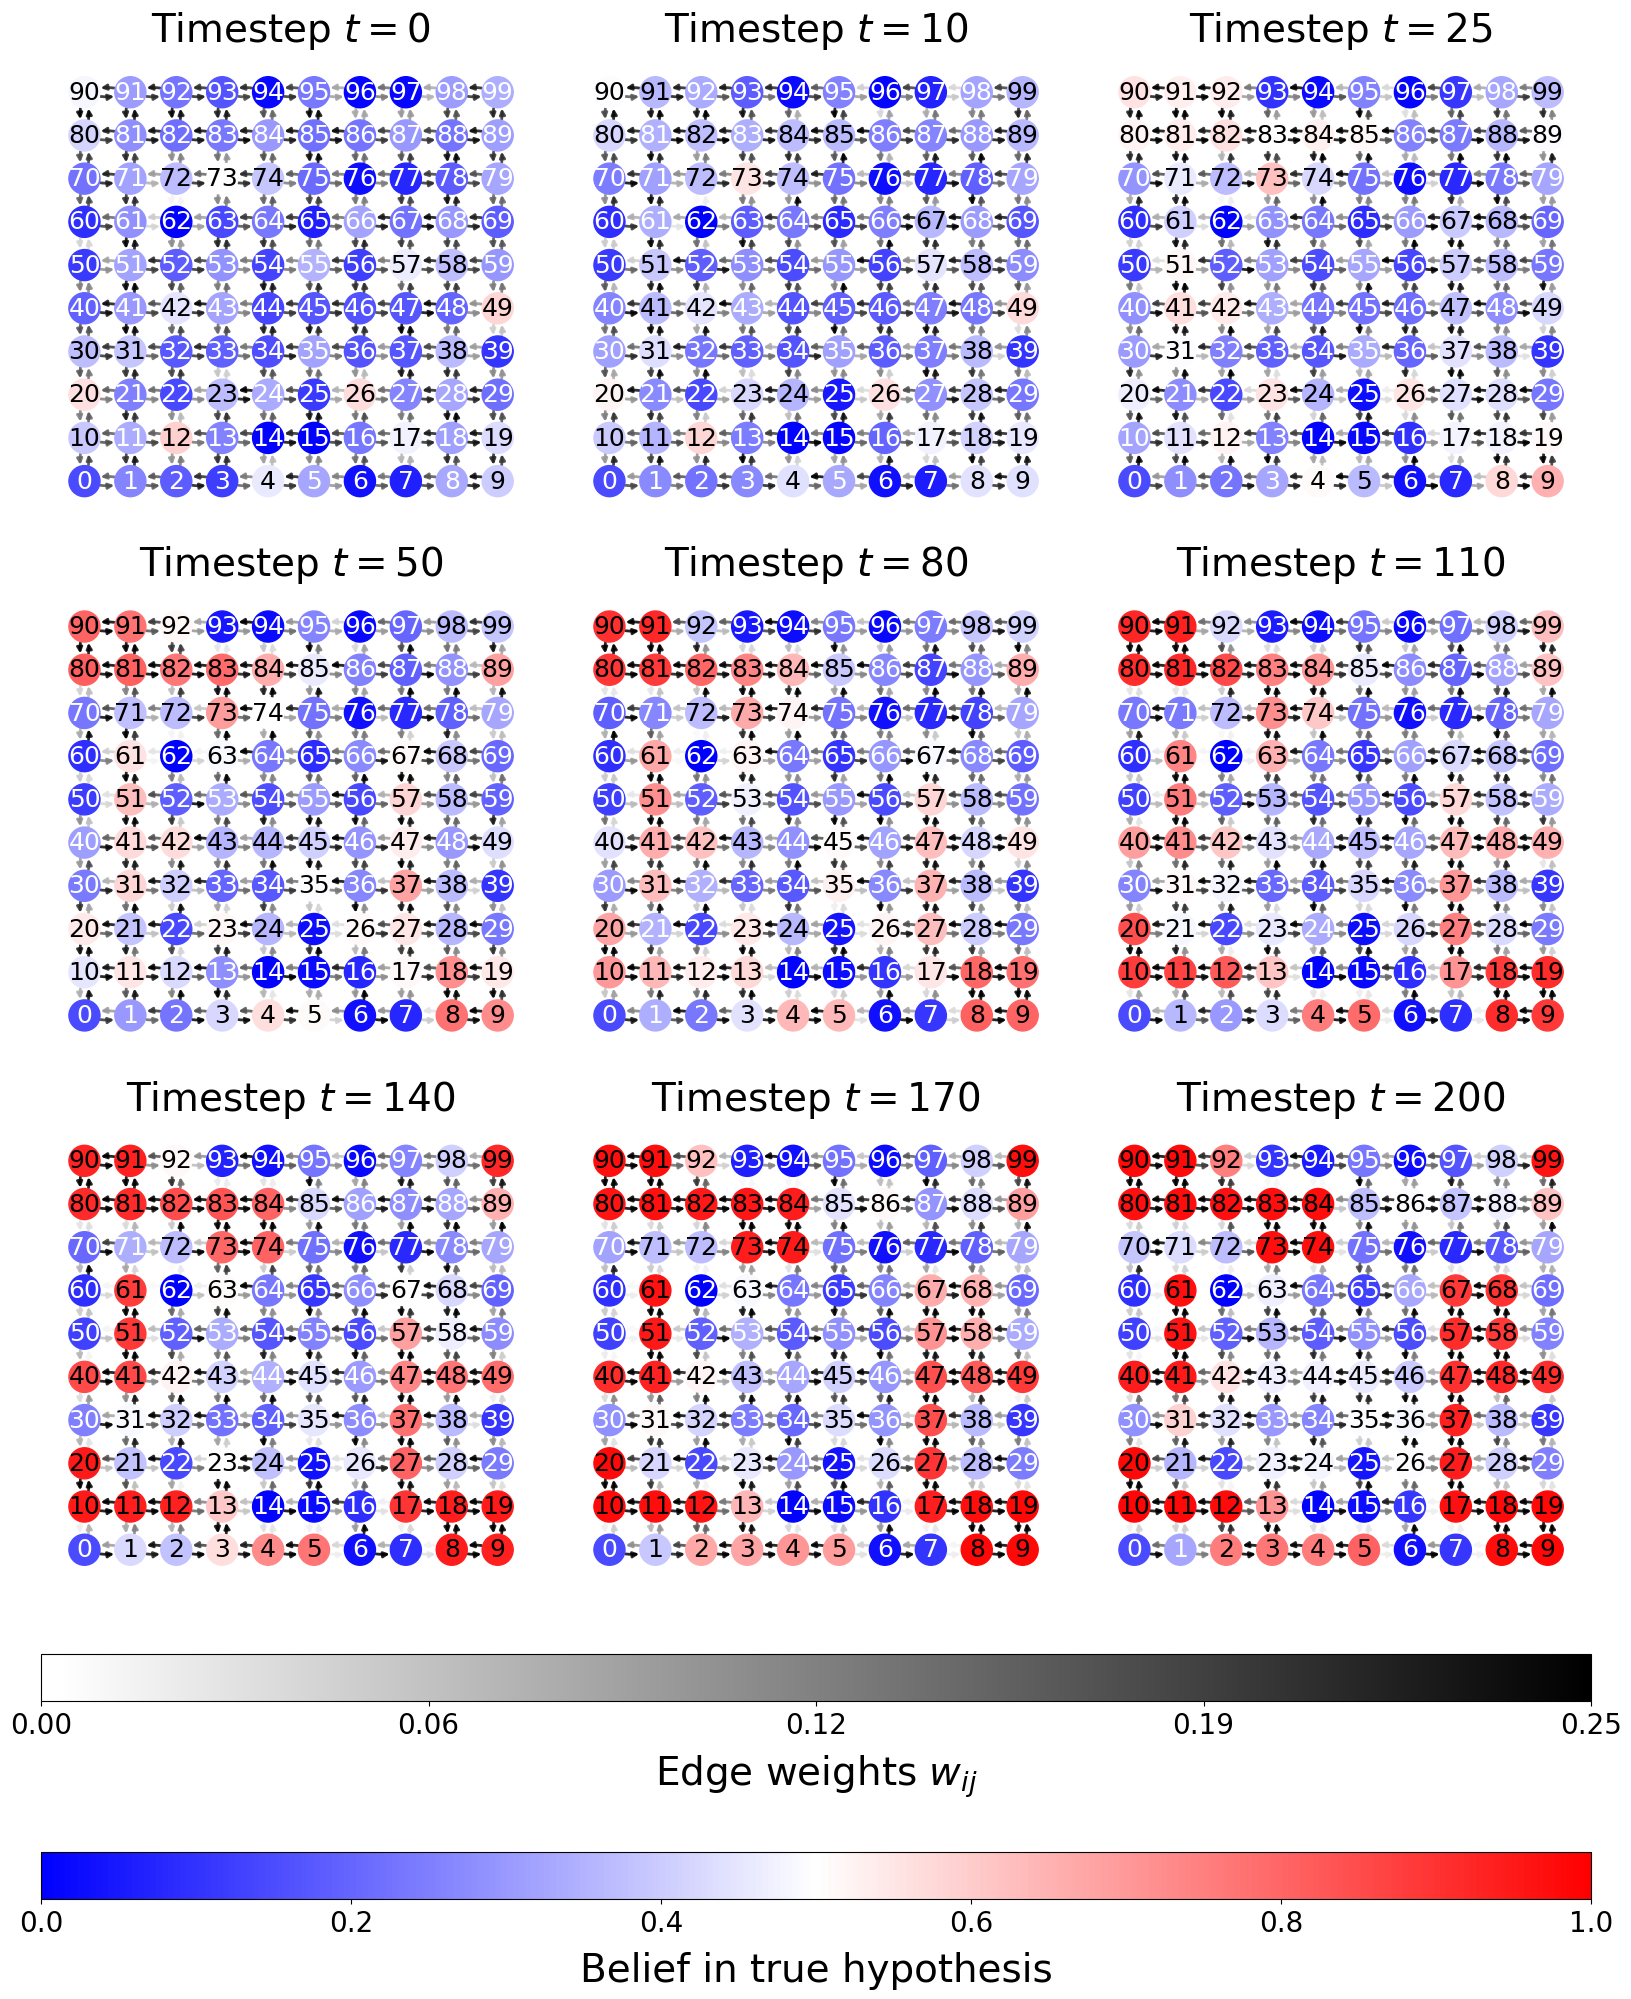

In [5]:
# --- Load your chosen file ---
def s_str(s):
    if s == 0.1:
        return "0p1"
    elif s == 0.6:
        return "0p6"
    elif s == 0.15:
        return "0p15"
    else:
        raise ValueError("Unsupported s value")
s=0.6
file_name = "DHT_N100_SQUARE_log_beliefs-F_weights-g_S0p15_flex0p5_signal-gaussian_gaussian-stds075_T200_1sims_1"
selected_ts = np.array([0, 10, 25, 50, 80, 110, 140, 170, 200])
# file_name = f"DHT_N100_SQUARE_S{s_str(s)}_flex0p5_gaussian-stds075_T150_1sims_1"
# selected_ts = np.array([0, 10, 25, 50, 75, 100, 120, 135, 150])
graph_file_name = "GRAPH-" + file_name
dir = "visualization"
plot_dir = "plots/useful_2"
file_path = os.path.join(dir, file_name + ".npz")
data = np.load(file_path)
graph_path = os.path.join(dir, graph_file_name + ".npz")
graph = np.load(graph_path)

# Extract relevant arrays
private_beliefs = data["private"]  # shape (T, N)
public_beliefs = data["public"]    # shape (T, N)
adj_matrix = graph['arr_0'][0]
print(adj_matrix.shape)  # should print 50

# --- Rebuild the graph from adjacency matrix ---
if adj_matrix is not None:
    G = nx.grid_2d_graph(int((np.sqrt(adj_matrix.shape[0]))), int((np.sqrt(adj_matrix.shape[0]))), periodic=True)
else:
    # if not saved, you can regenerate using your graph function
    raise ValueError("Adjacency matrix not found in the NPZ file.")

# --- Compute truthfulness ---
T = calculate_beliefs(private_beliefs, 3)  # shape (T, N), values 0–1
tau2 = calculate_beliefs(private_beliefs, 2)
F = calculate_beliefs(private_beliefs, 0)

# T = data["T3"]
# F = data["T0"]

# --- Choose 6 timesteps evenly spaced ---
num_timesteps = T.shape[0]
small_selected_ts = np.array([0, 2, 4, 8, 16, 32])
very_small_selected_ts = np.array([0, 1, 2, 4, 6, 8])

# --- Rebuild graph ---
L = int(np.sqrt(adj_matrix.shape[0]))  # should be 10 for N=100
G = nx.grid_2d_graph(L, L, periodic=True)
G = nx.convert_node_labels_to_integers(G, ordering="sorted")  # ensures 0..N-1

deg = np.asarray([G.degree(n) for n in range(G.number_of_nodes())], dtype=float)
deg[deg == 0] = 1.0

# --- positions consistent with integer labels ---
pos = {n: (n % L, n // L) for n in G.nodes()}

selected_agents = np.random.choice(int((adj_matrix.shape[0])), 5, replace=False)
timesteps = np.arange(T.shape[0])

# --- (optional but recommended) pick a fixed edge color scale across all panels ---
# Compute global min/max over the timesteps you plot so the edge colors are comparable.
all_w = []
for t in selected_ts:
    if t==selected_ts[-1]:
        _, w_t = edge_weights_from_beliefs(G, public_beliefs[0,t], private_beliefs[0,t-1], s=s)
    else:
        _, w_t = edge_weights_from_beliefs(G, public_beliefs[0,t+1], private_beliefs[0,t], s=s)
    all_w.append(w_t)
all_w = np.concatenate(all_w)
edge_vmin, edge_vmax = float(all_w.min()), float(all_w.max())

edge_cmap = plt.cm.binary   # pick whatever you like
node_cmap = "bwr"

# Plot beliefs for True hypothesis (3)
# plt.figure(figsize=(10, 6))
# for agent in selected_agents:
#     plt.plot(timesteps, T[:, agent], alpha=0.5, label=f"Agent {agent}")
# plt.title(f"Evolution of belief in the True hypothesis, s={s}, std=0.75, flex=0.5")
# plt.xlabel("timestep")
# plt.ylabel("Belief in True Hypothesis")
# plt.ylim(0, 1)
# plt.grid(True, alpha=0.3)
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
# plt.tight_layout()
# plt.savefig(os.path.join(dir, plot_dir, f"Belief_Evolution_True-hyp_{file_name}.png"))
# plt.show()

# # Plot beliefs for False hypothesis (0)
# plt.figure(figsize=(10, 6))
# for agent in selected_agents:
#     plt.plot(timesteps, F[:, agent], alpha=0.5, label=f"Agent {agent}")
# plt.title(f"Evolution of belief in the False hypothesis, s={s}, std=0.75, flex=0.5")
# plt.xlabel("timestep")
# plt.ylabel("Belief in False Hypothesis")
# plt.ylim(0, 1)
# plt.grid(True, alpha=0.3)
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
# plt.tight_layout()
# plt.savefig(os.path.join(dir, plot_dir, f"Belief_Evolution_False-hyp_{file_name}.png"))
# plt.show()

# --- Plot ---
tau1 = calculate_beliefs(private_beliefs, 1)
plot_grid_with_two_colorbars(
    selected_ts=selected_ts,
    node_values=T,
    private_beliefs=private_beliefs,
    public_beliefs=public_beliefs,
    title=fr"Evolution of belief in the true hypothesis, s={s}, std=0.75, flex=0.5",
    savepath=os.path.join(dir, plot_dir, f"TRUE_BELIEF_ts{selected_ts.min()}-{selected_ts.max()}{graph_file_name}.png"),
    G=G, pos=pos,
    node_cmap="bwr", edge_cmap=plt.cm.binary,
    edge_vmin=edge_vmin, edge_vmax=edge_vmax,
    s=s,
    belief_type="T"
)

# plot_grid_with_two_colorbars(
#     selected_ts=selected_ts,
#     node_values=F,
#     private_beliefs=private_beliefs,
#     public_beliefs=public_beliefs,
#     title=f"Evolution of belief in the False hypothesis, s={s}, std=0.75, flex=0.5",
#     savepath=os.path.join(dir, plot_dir, f"FALSE_BELIEF_ts{selected_ts.min()}-{selected_ts.max()}{graph_file_name}.png"),
#     G=G, pos=pos,
#     node_cmap="bwr", edge_cmap=plt.cm.binary,
#     edge_vmin=edge_vmin, edge_vmax=edge_vmax,
#     s=s,
#     belief_type='F'
# )

# plot_grid2x3_with_two_colorbars(
#     selected_ts=small_selected_ts,
#     node_values=T,
#     private_beliefs=private_beliefs,
#     public_beliefs=public_beliefs,
#     title=f"Evolution of belief in the True hypothesis, s={s}, std=0.75, flex=0.5",
#     savepath=os.path.join(dir, plot_dir, f"TRUE_BELIEF_ts{small_selected_ts.min()}-{small_selected_ts.max()}{graph_file_name}.png"),
#     G=G, pos=pos,
#     node_cmap="bwr", edge_cmap=plt.cm.binary,
#     edge_vmin=edge_vmin, edge_vmax=edge_vmax,
#     s=s,
#     belief_type='T')

# plot_grid2x3_with_two_colorbars(
#     selected_ts=small_selected_ts,
#     node_values=F,
#     private_beliefs=private_beliefs,
#     public_beliefs=public_beliefs,
#     title=f"Evolution of belief in the False hypothesis, s={s}, std=0.75, flex=0.5",
#     savepath=os.path.join(dir, plot_dir, f"FALSE_BELIEF_ts{small_selected_ts.min()}-{small_selected_ts.max()}{graph_file_name}.png"),
#     G=G, pos=pos,
#     node_cmap="bwr", edge_cmap=plt.cm.binary,
#     edge_vmin=edge_vmin, edge_vmax=edge_vmax,
#     s=s,
#     belief_type='F'
# )

# plot_grid2x3_with_two_colorbars(
#     selected_ts=very_small_selected_ts,
#     node_values=T,
#     private_beliefs=private_beliefs,
#     public_beliefs=public_beliefs,
#     title=f"Evolution of belief in the True hypothesis, s={s}, std=0.75, flex=0.5",
#     savepath=os.path.join(dir, plot_dir, f"TRUE_BELIEF_ts{very_small_selected_ts.min()}-{very_small_selected_ts.max()}{graph_file_name}.png"),
#     G=G, pos=pos,
#     node_cmap="bwr", edge_cmap=plt.cm.binary,
#     edge_vmin=edge_vmin, edge_vmax=edge_vmax,
#     s=s,
#     belief_type='T'
# )

# plot_grid2x3_with_two_colorbars(
#     selected_ts=very_small_selected_ts,
#     node_values=F,
#     private_beliefs=private_beliefs,
#     public_beliefs=public_beliefs,
#     title=f"Evolution of belief in the False hypothesis, s={s}, std=0.75, flex=0.5",
#     savepath=os.path.join(dir, plot_dir, f"FALSE_BELIEF_ts{very_small_selected_ts.min()}-{very_small_selected_ts.max()}{graph_file_name}.png"),
#     G=G, pos=pos,
#     node_cmap="bwr", edge_cmap=plt.cm.binary,
#     edge_vmin=edge_vmin, edge_vmax=edge_vmax,
#     s=s,
    # belief_type='F')

In [3]:
file_name = "DHT_N100_SQUARE_log_beliefs-F_weights-g_S0p15_flex0p5_signal-gaussian_gaussian-stds075_T200_1sims_1"
graph_file_name = "GRAPH-" + file_name
dir = "visualization"
plot_dir = "plots"
file_path = os.path.join(dir, file_name + ".npz")
data = np.load(file_path)
graph_path = os.path.join(dir, graph_file_name + ".npz")
graph = np.load(graph_path)
print(data.files)

['private', 'public']


['private', 'public']
(100, 100)


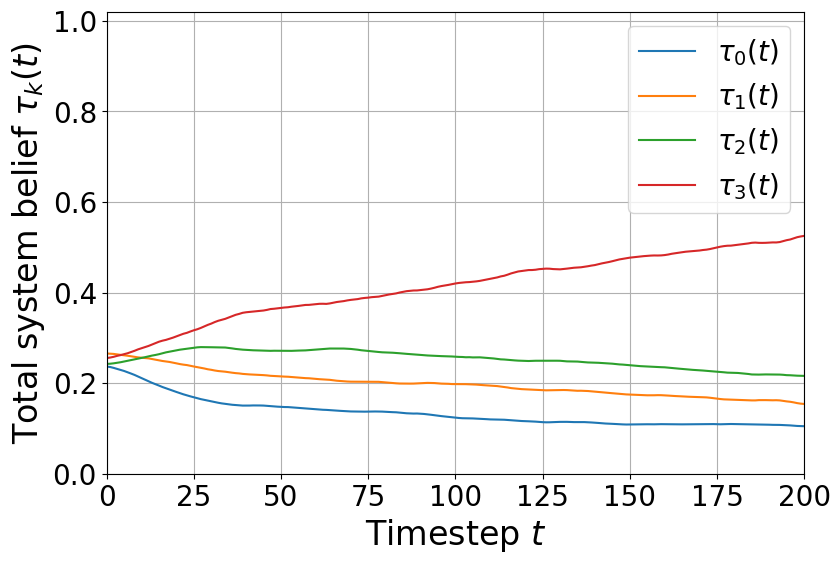

In [28]:
# --- Load your chosen file ---
from metrics import truthfulness
file_name = "DHT_N100_SQUARE_log_beliefs-F_weights-g_S0p15_flex0p5_signal-gaussian_gaussian-stds075_T200_1sims_1"
graph_file_name = "GRAPH-" + file_name
dir = "visualization"
plot_dir = "plots"
file_path = os.path.join(dir, file_name + ".npz")
data = np.load(file_path)
graph_path = os.path.join(dir, graph_file_name + ".npz")
graph = np.load(graph_path)
print(data.files)
# Extract relevant arrays
private_beliefs = data["private"]  # shape (T, N)
adj_matrix = graph['arr_0'][0]
print(adj_matrix.shape)  # should print 50

# --- Rebuild the graph from adjacency matrix ---
if adj_matrix is not None:
    G = nx.grid_2d_graph(int((np.sqrt(adj_matrix.shape[0]))), int((np.sqrt(adj_matrix.shape[0]))), periodic=True)
else:
    # if not saved, you can regenerate using your graph function
    raise ValueError("Adjacency matrix not found in the NPZ file.")

# --- Compute truthfulness ---
q3 = calculate_beliefs(private_beliefs, 3)  # shape (T, N), values 0–1
q2 = calculate_beliefs(private_beliefs, 2)
q1 = calculate_beliefs(private_beliefs, 1)
q0 = calculate_beliefs(private_beliefs, 0)

T1 = truthfulness(private_beliefs, 1)
T2 = truthfulness(private_beliefs, 2)
T3 = truthfulness(private_beliefs, 3)
T0 = truthfulness(private_beliefs, 0)

# --- Choose 6 timesteps evenly spaced ---
num_timesteps = T3.shape[0]
selected_ts = np.array([0, 10, 25, 50, 75, 100, 150, 200, 300])
small_selected_ts = np.array([0, 1, 2, 4, 6, 8])

# --- Layout (fixed for consistency) ---
pos = {(i, j): (i, j) for i, j in G.nodes()}
G = nx.convert_node_labels_to_integers(G)
pos = {n: (n % int((np.sqrt(adj_matrix.shape[0]))), n // int((np.sqrt(adj_matrix.shape[0])))) for n in range(G.number_of_nodes())}

selected_agents = np.random.choice(int((adj_matrix.shape[0])), 5, replace=False)
timesteps = np.arange(T3.shape[0])

# Plot beliefs for True hypothesis (3)
plt.figure(figsize=(9, 6))
plt.plot(T0, label=r'$\tau_0(t)$')
plt.plot(T1, label=r'$\tau_1(t)$')
plt.plot(T2, label=r'$\tau_2(t)$')
plt.plot(T3, label=r'$\tau_3(t)$')
plt.xlabel(r'Timestep $t$', fontsize=24)
plt.ylabel(r"Total system belief $\tau_k(t)$", fontsize=24)
plt.legend(fontsize=20)
plt.yticks(np.arange(0, 1.1, 0.2), fontsize=20)
plt.xticks(np.arange(0, 201, 25), fontsize=20)
plt.grid()
plt.xlim((0, 200))
plt.ylim((0,1.02))
plt.savefig("visualization/plots/useful_2/s0p15-beliefs.png", dpi=400, bbox_inches='tight')
plt.show()